# Heart Diesease Prediction

## PRCP-1016-HeartDieseasePred

In [1]:
# ── Install  packages (run once)
import subprocess, sys
pkgs = ['xgboost', 'lightgbm', 'imbalanced-learn', 'optuna', 'category_encoders']
for pkg in pkgs:
    try:
        __import__(pkg.replace('-', '_').split('[')[0])
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages ready')

✅ All packages ready


## Import Models

In [2]:
# ── Core Libraries ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')
print('✅ Libraries loaded')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

# ── Preprocessing ─────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# ── Class Imbalance ───────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Models ────────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, VotingClassifier, StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgbm_lib

# ── Hyperparameter Tuning ─────────────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Metrics ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)

print('✅ All libraries loaded successfully!')

✅ Libraries loaded
✅ All libraries loaded successfully!


## Load Data

In [3]:

VALUES_PATH = r'C:\Users\VIRAJ\Downloads\PRCP-1016-HeartDieseasePred\Data\values.csv'
LABELS_PATH = r'C:\Users\VIRAJ\Downloads\PRCP-1016-HeartDieseasePred\Data\labels.csv'

# Load features
values_df = pd.read_csv(VALUES_PATH)
print(f'Features loaded: {values_df.shape}')

# Merge with labels
labels_df = pd.read_csv(LABELS_PATH)
df = pd.merge(values_df, labels_df, on='patient_id', how='inner')
print(f'✅ Labels merged. Final shape: {df.shape}')

print(f'\nFinal df shape : {df.shape}')
df.head(3)

Features loaded: (180, 14)
✅ Labels merged. Final shape: (180, 15)

Final df shape : (180, 15)


,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1


## Data Quality Analysis

In [4]:
print('=' * 60)
print(f"{'DATASET OVERVIEW':^60}")
print('=' * 60)
print(f'  Total Rows       : {df.shape[0]:,}')
print(f'  Total Columns    : {df.shape[1]}')
print(f'  Memory Usage     : {df.memory_usage(deep=True).sum() / 1e3:.2f} KB')
print('=' * 60)

print('\n── Data Types ──')
print(df.dtypes.value_counts())

print('\n── Missing Values ──')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else '✅ No missing values found')

print('\n── Duplicate Rows ──')
dups = df.duplicated().sum()
print(f'✅ {dups} duplicates' if dups == 0 else f'⚠️  {dups} duplicates detected')

print('\n── Target Distribution ──')
vc = df['heart_disease_present'].value_counts().sort_index()
labels_map = {0: 'No Disease ', 1: 'Heart Disease'}
for cls, count in vc.items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'  {labels_map[cls]}: {count:>4,}  ({pct:5.1f}%)  {bar}')

                      DATASET OVERVIEW                      
  Total Rows       : 180
  Total Columns    : 15
  Memory Usage     : 39.51 KB

── Data Types ──
int64      12
object      2
float64     1
Name: count, dtype: int64

── Missing Values ──
✅ No missing values found

── Duplicate Rows ──
✅ 0 duplicates

── Target Distribution ──
  No Disease :  100  ( 55.6%)  ███████████████████████████
  Heart Disease:   80  ( 44.4%)  ██████████████████████


In [5]:
print('── Statistical Summary ──')
df.describe(include='all').T

── Statistical Summary ──


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,180,180,0z64un,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
slope_of_peak_exercise_st_segment,180.0,NaN,NaN,NaN,1.55,0.618838,1.0,1.0,1.0,2.0,3.0
thal,180,3,normal,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resting_blood_pressure,180.0,NaN,NaN,NaN,131.311111,17.010443,94.0,120.0,130.0,140.0,180.0
chest_pain_type,180.0,NaN,NaN,NaN,3.155556,0.938454,1.0,3.0,3.0,4.0,4.0
num_major_vessels,180.0,NaN,NaN,NaN,0.694444,0.969347,0.0,0.0,0.0,1.0,3.0
fasting_blood_sugar_gt_120_mg_per_dl,180.0,NaN,NaN,NaN,0.161111,0.368659,0.0,0.0,0.0,0.0,1.0
resting_ekg_results,180.0,NaN,NaN,NaN,1.05,0.998742,0.0,0.0,2.0,2.0,2.0
serum_cholesterol_mg_per_dl,180.0,NaN,NaN,NaN,249.211111,52.717969,126.0,213.75,245.5,281.25,564.0
oldpeak_eq_st_depression,180.0,NaN,NaN,NaN,1.01,1.121357,0.0,0.0,0.8,1.6,6.2


## EDA (Exploratory Data Analysis)

#### Target Distribution:-

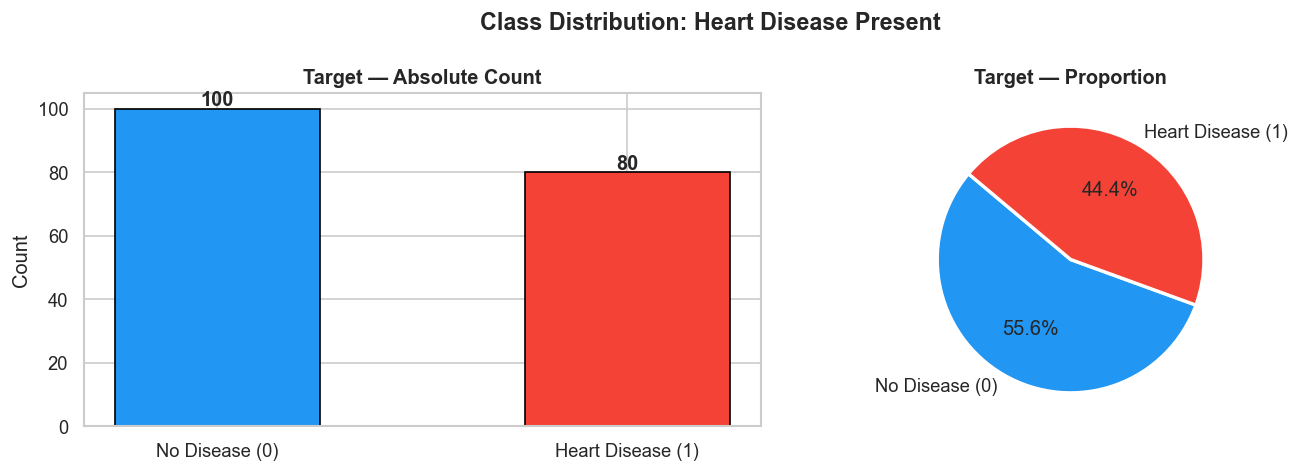


CLASS BALANCE ANALYSIS:
  No Disease (0)   : 100 (55.6%)
  Heart Disease (1): 80 (44.4%)

→ Mild imbalance (55.6% vs 44.4%). Accuracy alone will be misleading.
→ Primary metric: ROC-AUC (threshold-independent).
→ Secondary: F1-Score, Precision, Recall.
→ SMOTE will be tested to handle imbalance.



In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = df['heart_disease_present'].value_counts().sort_index()
pct = df['heart_disease_present'].value_counts(normalize=True).sort_index() * 100
cls_labels = ['No Disease (0)', 'Heart Disease (1)']
colours = ['#2196F3', '#F44336']

bars = axes[0].bar(cls_labels, vc.values, color=colours, edgecolor='black', width=0.5)
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Target — Absolute Count', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(pct.values, labels=cls_labels, autopct='%1.1f%%',
            colors=colours, startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Target — Proportion', fontweight='bold')

plt.suptitle('Class Distribution: Heart Disease Present', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print(f"""
CLASS BALANCE ANALYSIS:
  No Disease (0)   : {vc[0]} ({pct[0]:.1f}%)
  Heart Disease (1): {vc[1]} ({pct[1]:.1f}%)

→ Mild imbalance (55.6% vs 44.4%). Accuracy alone will be misleading.
→ Primary metric: ROC-AUC (threshold-independent).
→ Secondary: F1-Score, Precision, Recall.
→ SMOTE will be tested to handle imbalance.
""")

#### Numerical Feature Distributions by Class

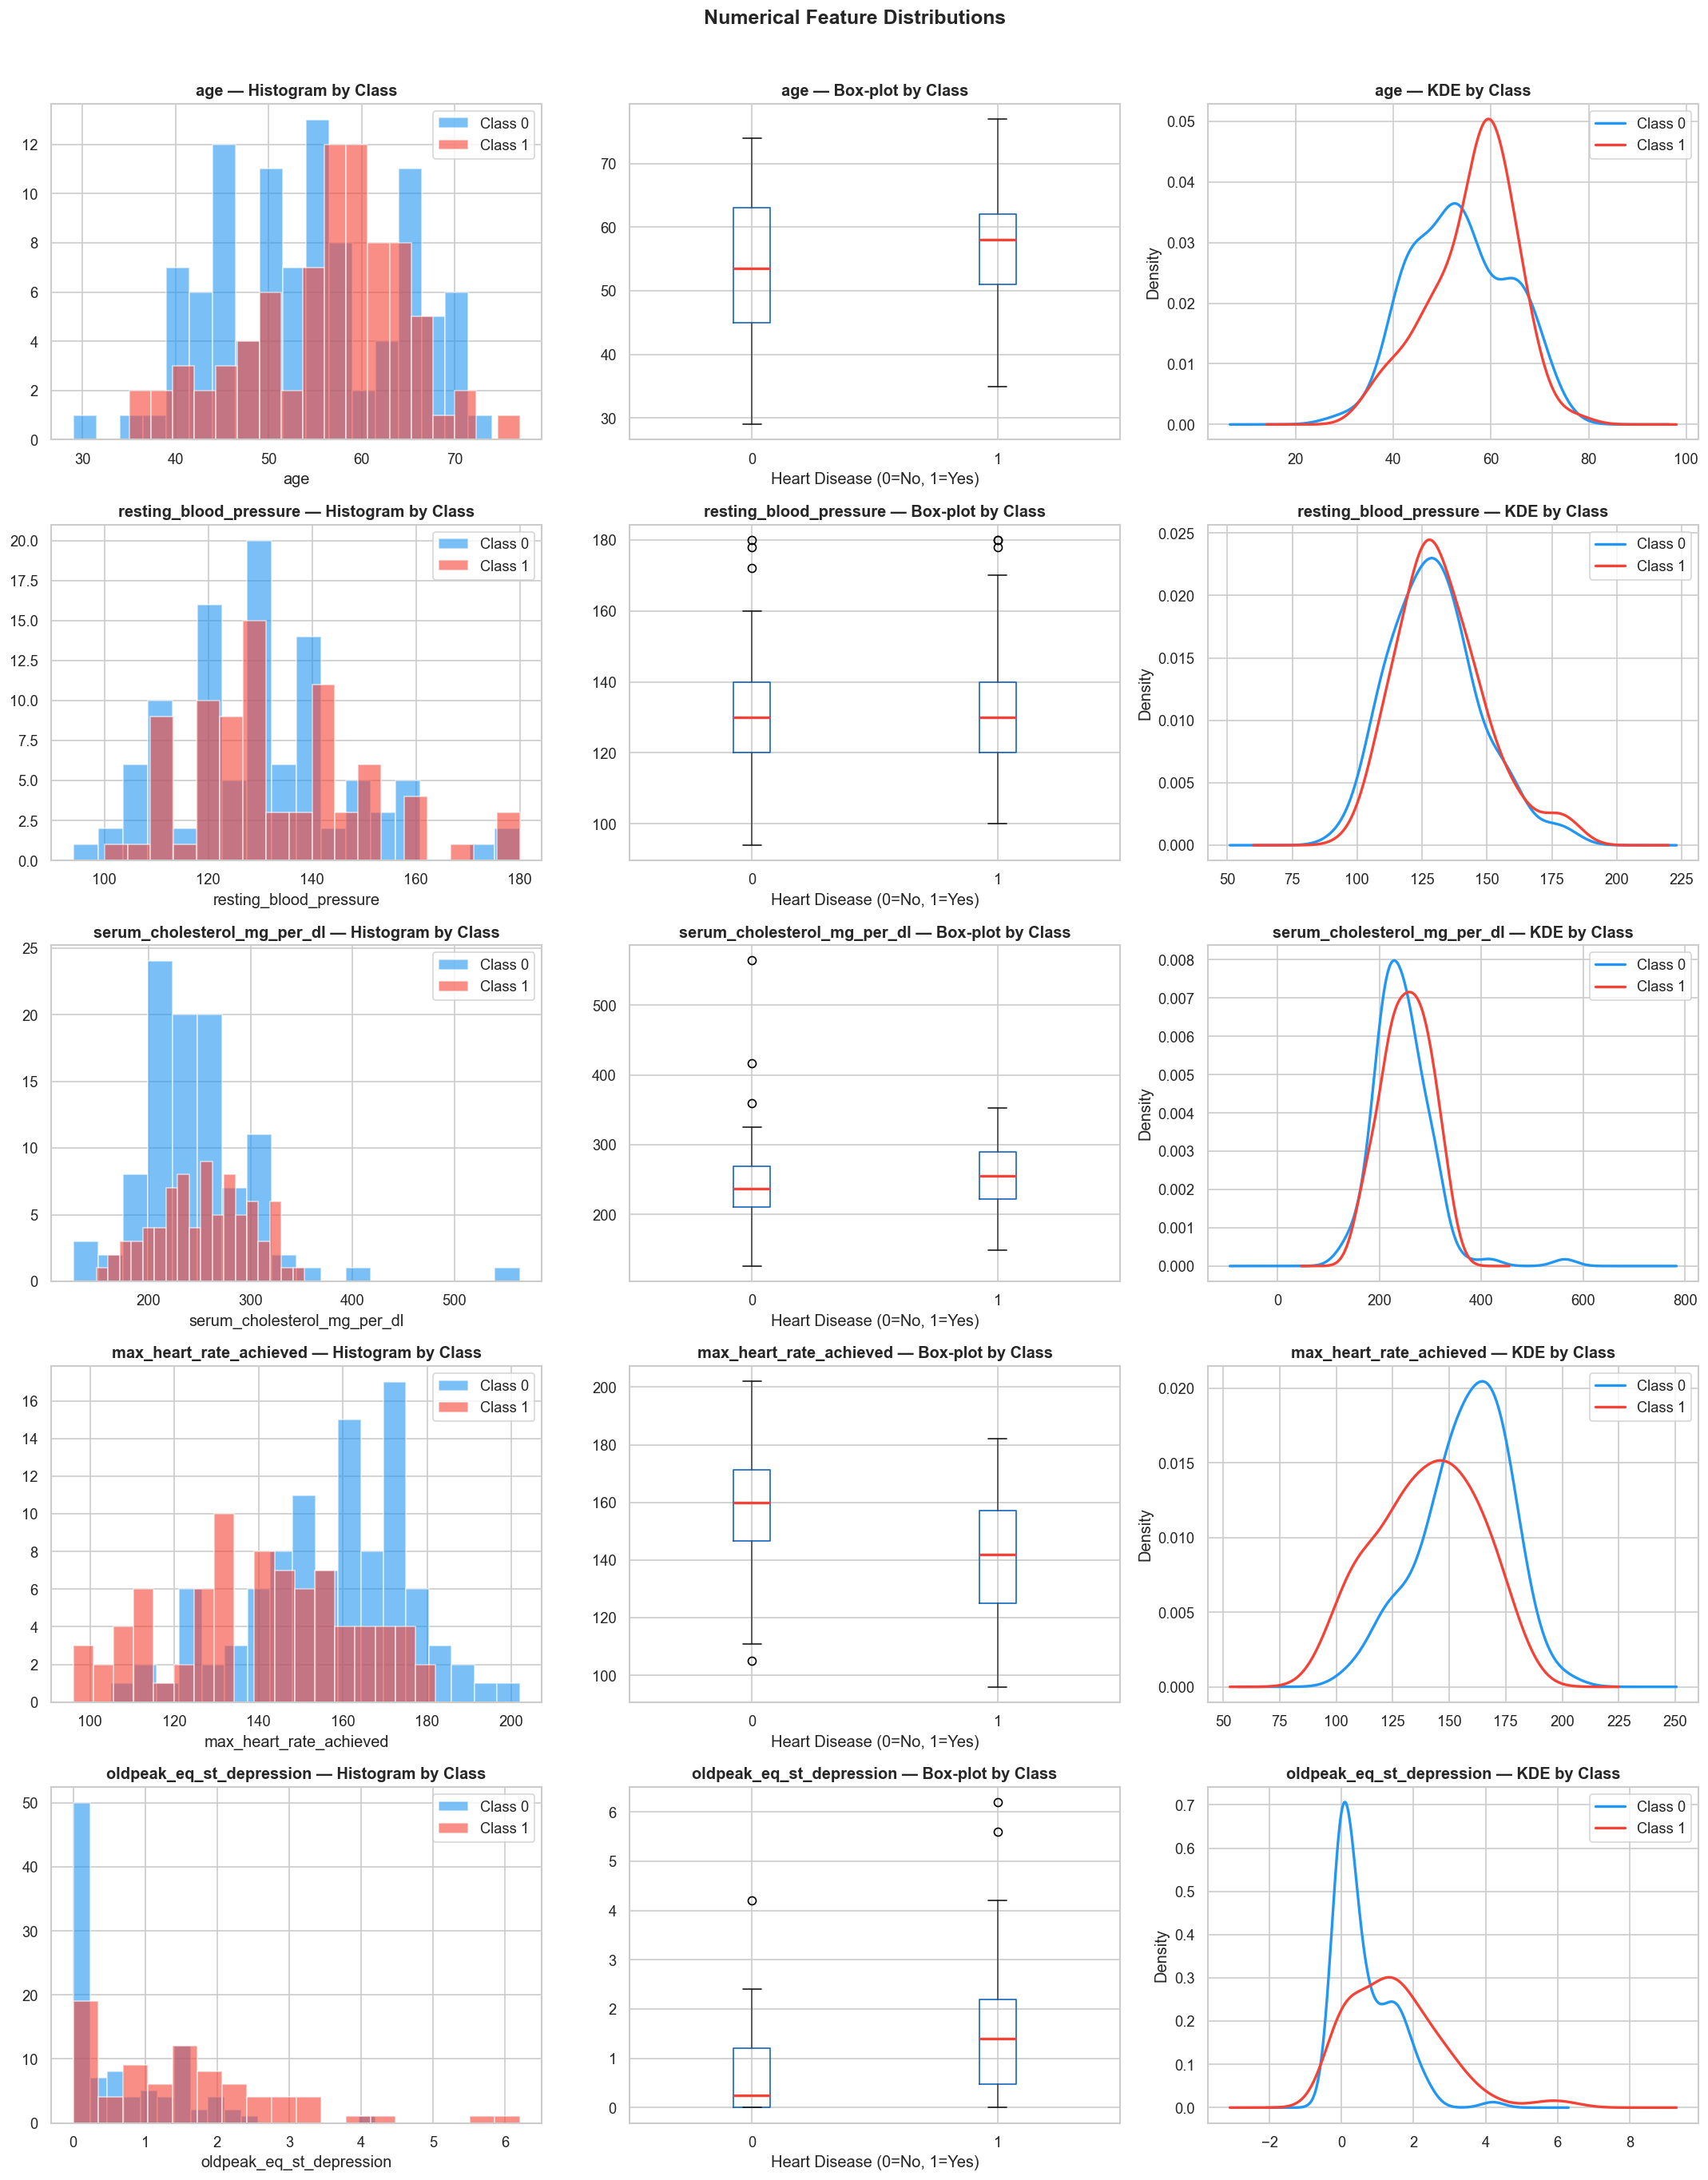

In [7]:
num_cols = ['age', 'resting_blood_pressure', 'serum_cholesterol_mg_per_dl',
            'max_heart_rate_achieved', 'oldpeak_eq_st_depression']

fig, axes = plt.subplots(len(num_cols), 3, figsize=(18, 4.5 * len(num_cols)))

for i, col in enumerate(num_cols):
    # Histogram by class
    for cls, c in zip([0, 1], ['#2196F3', '#F44336']):
        axes[i, 0].hist(df[df['heart_disease_present'] == cls][col],
                        bins=18, alpha=0.6, color=c,
                        label=f'Class {cls}', edgecolor='white')
    axes[i, 0].set_title(f'{col} — Histogram by Class', fontweight='bold')
    axes[i, 0].legend()
    axes[i, 0].set_xlabel(col)

    # Box-plot by class
    df.boxplot(column=col, by='heart_disease_present', ax=axes[i, 1],
               boxprops=dict(color='#1565C0'),
               medianprops=dict(color='#F44336', linewidth=2))
    axes[i, 1].set_title(f'{col} — Box-plot by Class', fontweight='bold')
    axes[i, 1].set_xlabel('Heart Disease (0=No, 1=Yes)')
    plt.suptitle('')

    # KDE
    for cls, c in zip([0, 1], ['#2196F3', '#F44336']):
        df[df['heart_disease_present'] == cls][col].plot(
            kind='kde', ax=axes[i, 2], color=c, label=f'Class {cls}', linewidth=2)
    axes[i, 2].set_title(f'{col} — KDE by Class', fontweight='bold')
    axes[i, 2].legend()

plt.suptitle('Numerical Feature Distributions', fontweight='bold', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

#### Categorical Feature Distributions by Class

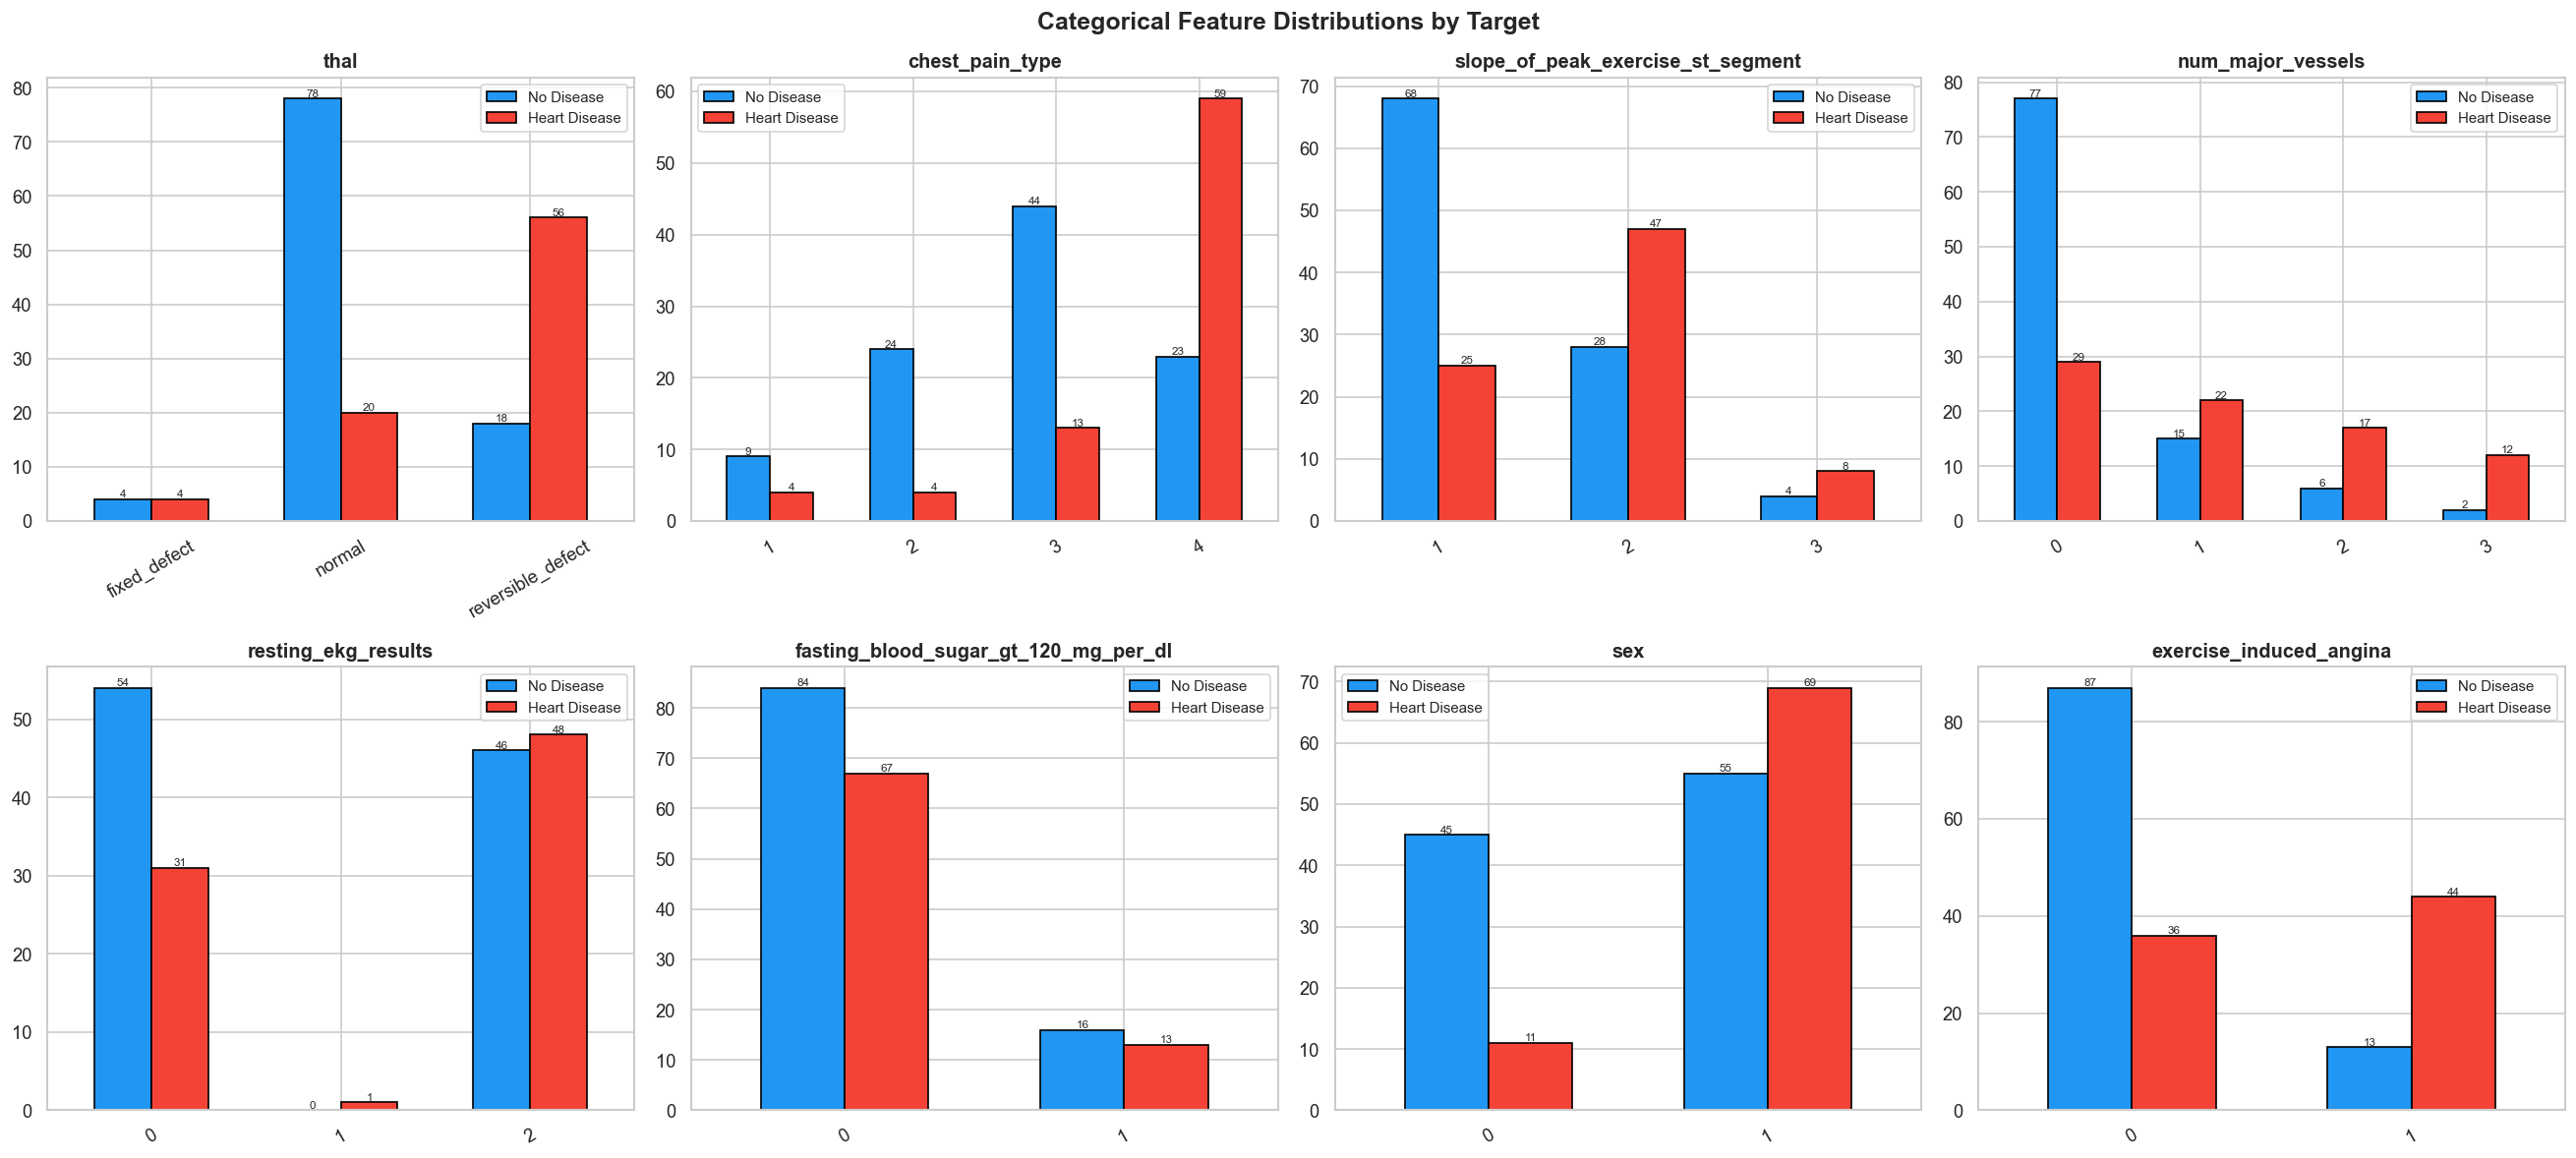

In [8]:
cat_cols_eda = ['thal', 'chest_pain_type', 'slope_of_peak_exercise_st_segment',
                'num_major_vessels', 'resting_ekg_results',
                'fasting_blood_sugar_gt_120_mg_per_dl', 'sex', 'exercise_induced_angina']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.ravel()

for i, col in enumerate(cat_cols_eda):
    ct = pd.crosstab(df[col], df['heart_disease_present'])
    ct.plot(kind='bar', ax=axes[i], color=['#2196F3', '#F44336'],
            edgecolor='black', rot=30, width=0.6)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(['No Disease', 'Heart Disease'], fontsize=9)
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%d', fontsize=7)

plt.suptitle('Categorical Feature Distributions by Target', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

#### Outlier Analysis (IQR Method) — specific observations

In [9]:
print('=' * 65)
print('  OUTLIER ANALYSIS (IQR Method)')
print('=' * 65)

for col in ['age', 'resting_blood_pressure', 'serum_cholesterol_mg_per_dl',
            'max_heart_rate_achieved', 'oldpeak_eq_st_depression']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lo) | (df[col] > hi)]
    pct_hd = (outliers['heart_disease_present'] == 1).mean() * 100 if len(outliers) else 0
    print(f'\n  {col}')
    print(f'    IQR bounds : [{lo:.2f}, {hi:.2f}]')
    print(f'    Outliers   : {len(outliers)} rows')
    if len(outliers):
        print(f'    Values     : {sorted(outliers[col].unique().tolist())}')
        print(f'    % Heart Disease among outliers: {pct_hd:.1f}%')

print("""
KEY OBSERVATIONS:
  • resting_blood_pressure : High values (>170 mmHg) = clinical hypertension — medically valid, KEEP.
  • serum_cholesterol      : Values >350 mg/dl = hypercholesterolaemia — medically valid, KEEP.
  • oldpeak_eq_st_depression: High values strongly linked to ischaemia — clinically meaningful, KEEP.
  • max_heart_rate_achieved : Low outliers = poor cardiac reserve — predictive signal, KEEP.

→ Decision: No outliers removed. All values are medically plausible.
  Tree-based models are naturally robust to outliers.
""")

  OUTLIER ANALYSIS (IQR Method)

  age
    IQR bounds : [27.00, 83.00]
    Outliers   : 0 rows

  resting_blood_pressure
    IQR bounds : [90.00, 170.00]
    Outliers   : 6 rows
    Values     : [172, 178, 180]
    % Heart Disease among outliers: 50.0%

  serum_cholesterol_mg_per_dl
    IQR bounds : [112.50, 382.50]
    Outliers   : 2 rows
    Values     : [417, 564]
    % Heart Disease among outliers: 0.0%

  max_heart_rate_achieved
    IQR bounds : [80.62, 217.62]
    Outliers   : 0 rows

  oldpeak_eq_st_depression
    IQR bounds : [-2.40, 4.00]
    Outliers   : 4 rows
    Values     : [4.2, 5.6, 6.2]
    % Heart Disease among outliers: 75.0%

KEY OBSERVATIONS:
  • resting_blood_pressure : High values (>170 mmHg) = clinical hypertension — medically valid, KEEP.
  • serum_cholesterol      : Values >350 mg/dl = hypercholesterolaemia — medically valid, KEEP.
  • oldpeak_eq_st_depression: High values strongly linked to ischaemia — clinically meaningful, KEEP.
  • max_heart_rate_achieved 

#### Correlation Heatmap + Target Correlation Bar Chart

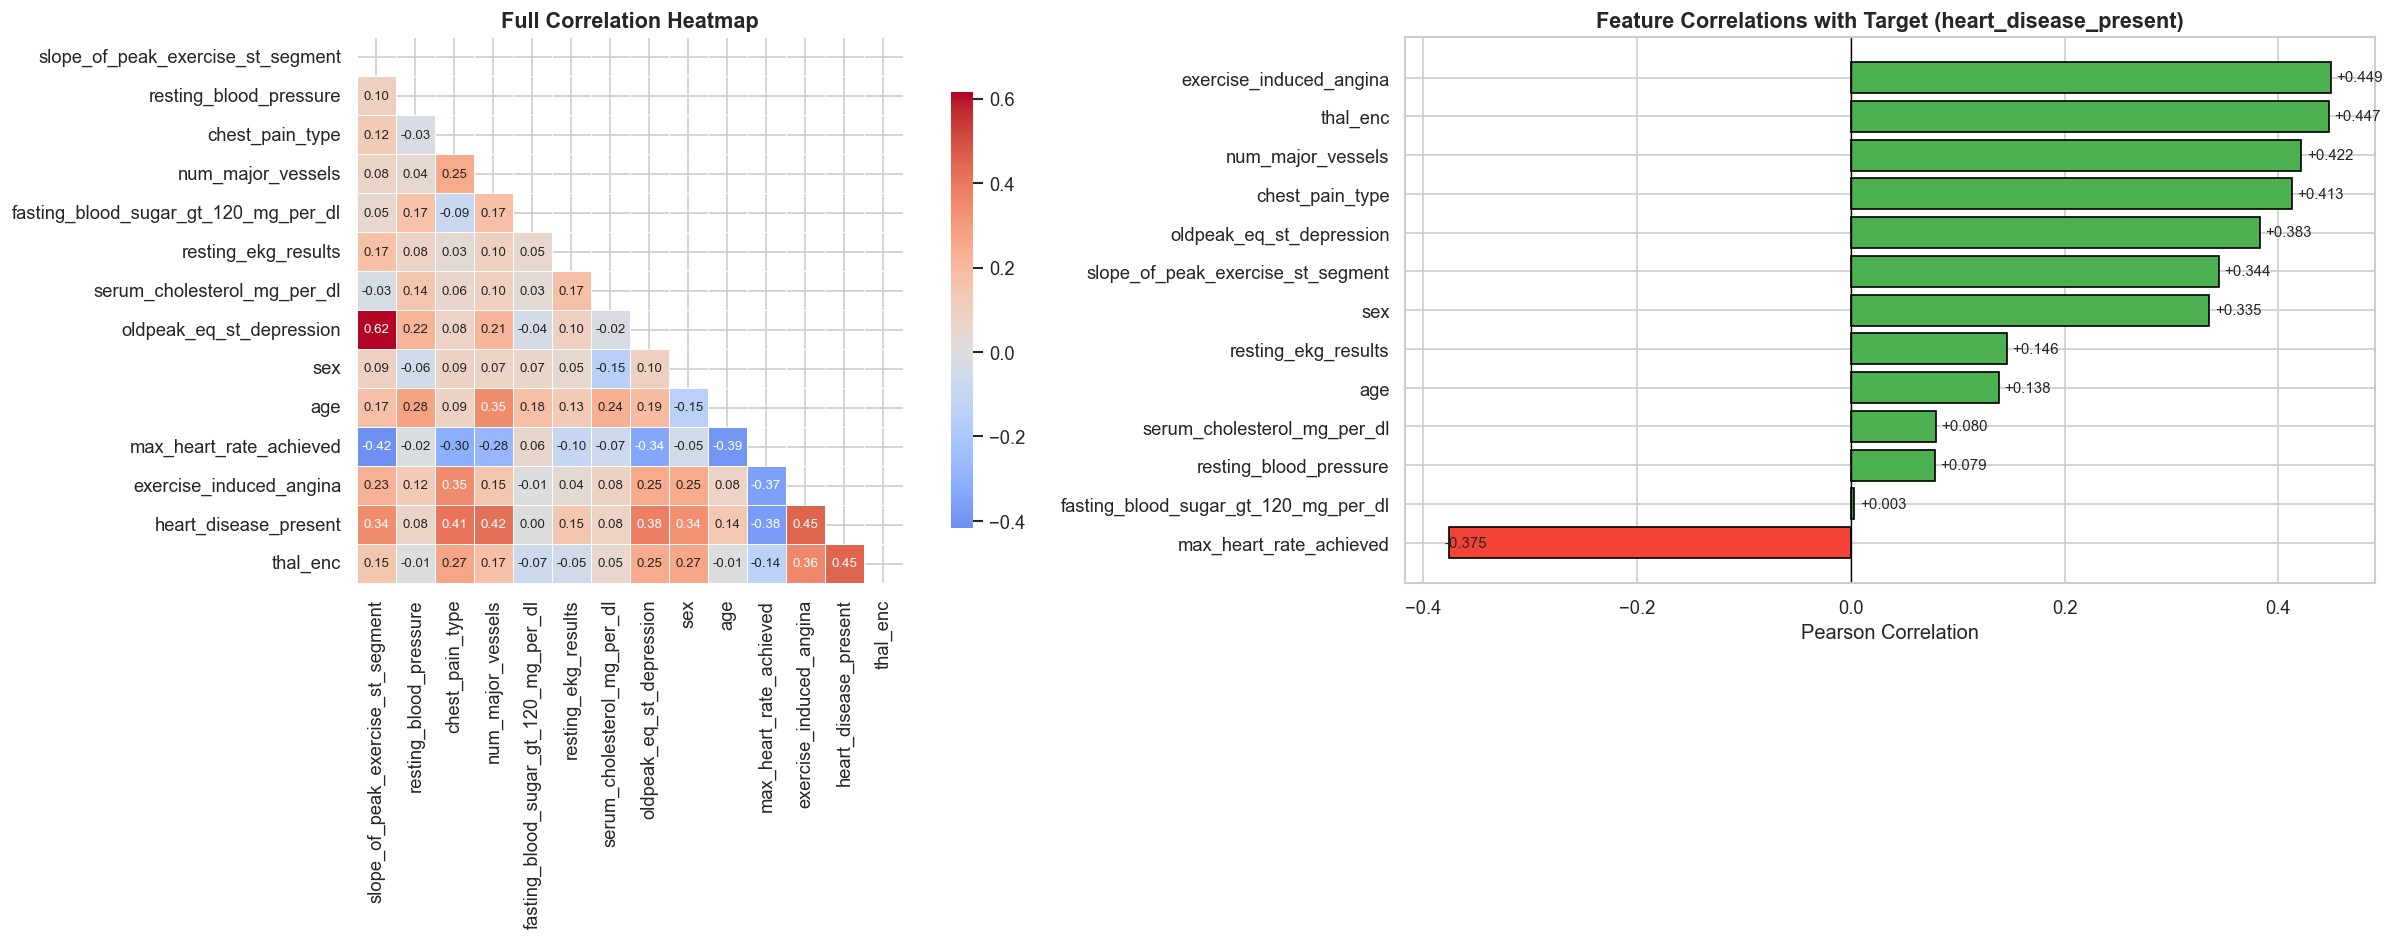


── Feature-Target Correlation (|r| ranked) ──
  exercise_induced_angina                       r = +0.449   |r| = 0.449
  thal_enc                                      r = +0.447   |r| = 0.447
  num_major_vessels                             r = +0.422   |r| = 0.422
  chest_pain_type                               r = +0.413   |r| = 0.413
  oldpeak_eq_st_depression                      r = +0.383   |r| = 0.383
  max_heart_rate_achieved                       r = -0.375   |r| = 0.375
  slope_of_peak_exercise_st_segment             r = +0.344   |r| = 0.344
  sex                                           r = +0.335   |r| = 0.335
  resting_ekg_results                           r = +0.146   |r| = 0.146
  age                                           r = +0.138   |r| = 0.138
  serum_cholesterol_mg_per_dl                   r = +0.080   |r| = 0.080
  resting_blood_pressure                        r = +0.079   |r| = 0.079
  fasting_blood_sugar_gt_120_mg_per_dl          r = +0.003   |r| = 0.003

KEY

In [10]:
df_corr = df.copy()
le_thal = LabelEncoder()
df_corr['thal_enc'] = le_thal.fit_transform(df_corr['thal'])
df_corr.drop(columns=['patient_id', 'thal'], inplace=True)

corr = df_corr.corr()

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Full heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=axes[0], linewidths=0.5,
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
axes[0].set_title('Full Correlation Heatmap', fontweight='bold', fontsize=13)

# Target correlations — sorted
target_corr = corr['heart_disease_present'].drop('heart_disease_present').sort_values()
colours_bar = ['#F44336' if v < 0 else '#4CAF50' for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colours_bar, edgecolor='black')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Feature Correlations with Target (heart_disease_present)',
                   fontweight='bold', fontsize=13)
axes[1].set_xlabel('Pearson Correlation')
for i, (v, label) in enumerate(zip(target_corr.values, target_corr.index)):
    axes[1].text(v + 0.005 * np.sign(v), i, f'{v:+.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\n── Feature-Target Correlation (|r| ranked) ──')
for feat, val in target_corr.abs().sort_values(ascending=False).items():
    direction = corr.loc[feat, 'heart_disease_present']
    print(f'  {feat:<45} r = {direction:+.3f}   |r| = {val:.3f}')

print("""
KEY INSIGHTS:
  • exercise_induced_angina  (+): Chest pain during exercise = strong disease indicator.
  • num_major_vessels        (+): More blocked vessels → higher disease risk.
  • oldpeak_eq_st_depression (+): Greater ST depression = myocardial ischaemia.
  • max_heart_rate_achieved  (-): Lower max HR = reduced cardiac capacity = higher risk.
  • thal (encoded)           (+): Defect type strongly linked to disease.
  • fasting_blood_sugar      ( ): Weakest correlation — retained for medical completeness.
""")

## Preprocessing and Feature Engineering

In [11]:
# ── Step 1: Encode categorical column 'thal' ──────────────────────────────────
# 'thal' has 3 levels: normal, fixed_defect, reversible_defect.
# One-Hot Encoding used — avoids imposing a false ordinal relationship.
df_proc = df.copy()
thal_dummies = pd.get_dummies(df_proc['thal'], prefix='thal', drop_first=False)
df_proc = pd.concat([df_proc.drop(columns=['thal']), thal_dummies], axis=1)
print(f'After OHE for thal — shape: {df_proc.shape}')
print('New thal columns:', [c for c in df_proc.columns if 'thal' in c])

After OHE for thal — shape: (180, 17)
New thal columns: ['thal_fixed_defect', 'thal_normal', 'thal_reversible_defect']


In [12]:
# ── Step 2: Feature Engineering — 5 domain-informed features ─────────────────
# Every feature below has an explicit clinical / physiological rationale.

# (a) age_risk
# Rationale: ACC/AHA guidelines classify >55 yr males and >65 yr females as
# high-risk. We use 55 as a conservative unisex threshold.
df_proc['age_risk'] = (df_proc['age'] > 55).astype(int)

# (b) st_severity
# Rationale: Combines oldpeak (ST depression magnitude) with the ST slope.
# A large depression on a downsloping (slope=3) segment is the most dangerous
# ECG pattern for coronary artery disease.
df_proc['st_severity'] = (
    df_proc['oldpeak_eq_st_depression'] * df_proc['slope_of_peak_exercise_st_segment']
)

# (c) cardiac_stress_index
# Rationale: Patients who achieve a low max HR relative to resting BP have
# limited cardiac reserve — a known predictor of coronary artery disease.
df_proc['cardiac_stress_index'] = (
    df_proc['max_heart_rate_achieved'] / (df_proc['resting_blood_pressure'] + 1)
)

# (d) angina_flag
# Rationale: Combines exercise-induced angina (direct ischaemia symptom) with
# atypical/typical chest pain (types 3–4). Both are direct markers of coronary
# ischaemia — combined flag strengthens the signal.
df_proc['angina_flag'] = (
    (df_proc['exercise_induced_angina'] == 1) |
    (df_proc['chest_pain_type'] >= 3)
).astype(int)

# (e) vessel_defect_score
# Rationale: Multiplies blocked major vessels by thallium defect presence.
# A patient with both vessel blockage AND a thallium perfusion defect carries
# compounding structural cardiac risk.
thal_defect = df_proc.get('thal_reversible_defect', 0) + df_proc.get('thal_fixed_defect', 0)
df_proc['vessel_defect_score'] = df_proc['num_major_vessels'] * thal_defect

eng_feats = ['age_risk', 'st_severity', 'cardiac_stress_index', 'angina_flag', 'vessel_defect_score']
print('✅ Engineered features added:')
for f in eng_feats:
    r = df_proc[f].corr(df_proc['heart_disease_present'])
    print(f'   {f:<30}  corr with target = {r:+.3f}')

print(f'\nFinal feature set shape: {df_proc.shape}')

✅ Engineered features added:
   age_risk                        corr with target = +0.221
   st_severity                     corr with target = +0.370
   cardiac_stress_index            corr with target = -0.337
   angina_flag                     corr with target = +0.252
   vessel_defect_score             corr with target = +0.461

Final feature set shape: (180, 22)


#### Train-Test Split (stratified)

In [13]:
# ── Step 3: Train-Test Split (stratified) ─────────────────────────────────────
df_proc.drop(columns=['patient_id'], inplace=True)

X = df_proc.drop(columns=['heart_disease_present'])
y = df_proc['heart_disease_present']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Train target ratio:\n{y_train.value_counts(normalize=True).round(3)}')

# ── Step 4: Scaling (fit on train ONLY — no leakage) ─────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('\n✅ StandardScaler fit on train, applied to test — no leakage.')

# ── Step 5: SMOTE (applied to train only) ────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_sm,    y_train_sm    = smote.fit_resample(X_train,    y_train)
X_train_sm_sc, y_train_sm_sc = smote.fit_resample(X_train_sc, y_train)

print(f'\nSMOTE resampled train (raw)    : {X_train_sm.shape}')
print(f'SMOTE resampled train (scaled) : {X_train_sm_sc.shape}')
print(f'After SMOTE target split: {pd.Series(y_train_sm).value_counts().to_dict()}')

Train : (144, 20)  |  Test : (36, 20)
Train target ratio:
heart_disease_present
0    0.556
1    0.444
Name: proportion, dtype: float64

✅ StandardScaler fit on train, applied to test — no leakage.

SMOTE resampled train (raw)    : (160, 20)
SMOTE resampled train (scaled) : (160, 20)
After SMOTE target split: {0: 80, 1: 80}


## Model Evaluation Framework

In [14]:
# ── Evaluation helper — consistent across ALL models ──────────────────────────
# ROC-AUC used as primary CV metric for ALL models (consistent — avoids the
# PRCP-1011 mistake of using different scoring metrics per model).
results = []
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(name, model, Xtr, ytr, Xte, yte):
    """Fit, cross-validate (ROC-AUC), predict, and record full metrics."""
    # Cross-validation on training data
    cv_scores = cross_val_score(model, Xtr, ytr, cv=SKF, scoring='roc_auc', n_jobs=-1)

    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(Xte)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(Xte)
    else:
        y_prob = y_pred.astype(float)

    entry = {
        'Model'       : name,
        'CV ROC-AUC'  : round(cv_scores.mean(), 4),
        'CV Std'      : round(cv_scores.std(),  4),
        'Test Acc'    : round(accuracy_score(yte, y_pred), 4),
        'Test ROC-AUC': round(roc_auc_score(yte, y_prob), 4),
        'F1'          : round(f1_score(yte, y_pred), 4),
        'Precision'   : round(precision_score(yte, y_pred), 4),
        'Recall'      : round(recall_score(yte, y_pred), 4),
        '_model'      : model,
        '_y_pred'     : y_pred,
        '_y_prob'     : y_prob,
    }
    results.append(entry)
    return entry

print('✅ Evaluation framework ready (CV scoring: roc_auc — consistent across all models)')
print('Models to train: Logistic Regression | Decision Tree | Random Forest | Extra Trees |')
print('                 Gradient Boosting | KNN | Naive Bayes | SVM | XGBoost | LightGBM')

✅ Evaluation framework ready (CV scoring: roc_auc — consistent across all models)
Models to train: Logistic Regression | Decision Tree | Random Forest | Extra Trees |
                 Gradient Boosting | KNN | Naive Bayes | SVM | XGBoost | LightGBM


## Model Training

In [15]:
print('Starting model training...\n')
print(f"{'Model':<28} {'CV ROC-AUC':>12} {'Test AUC':>10} {'F1':>8} {'Recall':>8}")
print('-' * 72)

# ── 1. Logistic Regression (Baseline) ────────────────────────────────────────
r = evaluate_model(
    'Logistic Regression',
    LogisticRegression(C=0.1, max_iter=500, solver='lbfgs', random_state=42),
    X_train_sm_sc, y_train_sm_sc, X_test_sc, y_test
)
print(f"{'Logistic Regression':<28} {r['CV ROC-AUC']:>12.4f} {r['Test ROC-AUC']:>10.4f} {r['F1']:>8.4f} {r['Recall']:>8.4f}")

# ── 2. Decision Tree ──────────────────────────────────────────────────────────
r = evaluate_model(
    'Decision Tree',
    DecisionTreeClassifier(max_depth=5, min_samples_split=5, criterion='gini',
                            class_weight='balanced', random_state=42),
    X_train_sm, y_train_sm, X_test, y_test
)
print(f"{'Decision Tree':<28} {r['CV ROC-AUC']:>12.4f} {r['Test ROC-AUC']:>10.4f} {r['F1']:>8.4f} {r['Recall']:>8.4f}")

# ── 3. Random Forest ─────────────────────────────────────────────────────────
r = evaluate_model(
    'Random Forest',
    RandomForestClassifier(n_estimators=300, max_depth=None, min_samples_split=5,
                            min_samples_leaf=2, max_features='sqrt',
                            class_weight='balanced_subsample',
                            random_state=42, n_jobs=-1),
    X_train_sm, y_train_sm, X_test, y_test
)
print(f"{'Random Forest':<28} {r['CV ROC-AUC']:>12.4f} {r['Test ROC-AUC']:>10.4f} {r['F1']:>8.4f} {r['Recall']:>8.4f}")

# ── 4. Extra Trees ───────────────────────────────────────────────────────────
r = evaluate_model(
    'Extra Trees',
    ExtraTreesClassifier(n_estimators=300, max_depth=None, min_samples_split=5,
                          min_samples_leaf=2, max_features='sqrt',
                          class_weight='balanced_subsample',
                          random_state=42, n_jobs=-1),
    X_train_sm, y_train_sm, X_test, y_test
)
print(f"{'Extra Trees':<28} {r['CV ROC-AUC']:>12.4f} {r['Test ROC-AUC']:>10.4f} {r['F1']:>8.4f} {r['Recall']:>8.4f}")

# ── 5. Gradient Boosting ─────────────────────────────────────────────────────
r = evaluate_model(
    'Gradient Boosting',
    GradientBoostingClassifier(n_estimators=200, learning_rate=0.08, max_depth=5,
                                min_samples_split=10, subsample=0.85,
                                max_features='sqrt', random_state=42),
    X_train_sm, y_train_sm, X_test, y_test
)
print(f"{'Gradient Boosting':<28} {r['CV ROC-AUC']:>12.4f} {r['Test ROC-AUC']:>10.4f} {r['F1']:>8.4f} {r['Recall']:>8.4f}")

# ── 6. KNN (distance-weighted) ───────────────────────────────────────────────
r = evaluate_model(
    'KNN',
    KNeighborsClassifier(n_neighbors=11, weights='distance', metric='euclidean', n_jobs=-1),
    X_train_sm_sc, y_train_sm_sc, X_test_sc, y_test
)
print(f"{'KNN':<28} {r['CV ROC-AUC']:>12.4f} {r['Test ROC-AUC']:>10.4f} {r['F1']:>8.4f} {r['Recall']:>8.4f}")

# ── 7. Naive Bayes ───────────────────────────────────────────────────────────
r = evaluate_model(
    'Naive Bayes',
    GaussianNB(var_smoothing=1e-8),
    X_train_sm_sc, y_train_sm_sc, X_test_sc, y_test
)
print(f"{'Naive Bayes':<28} {r['CV ROC-AUC']:>12.4f} {r['Test ROC-AUC']:>10.4f} {r['F1']:>8.4f} {r['Recall']:>8.4f}")

# ── 8. SVM (RBF kernel, probability calibrated) ──────────────────────────────
r = evaluate_model(
    'SVM',
    SVC(C=10, gamma=0.01, kernel='rbf', probability=True, random_state=42),
    X_train_sm_sc, y_train_sm_sc, X_test_sc, y_test
)
print(f"{'SVM':<28} {r['CV ROC-AUC']:>12.4f} {r['Test ROC-AUC']:>10.4f} {r['F1']:>8.4f} {r['Recall']:>8.4f}")

# ── 9. XGBoost ───────────────────────────────────────────────────────────────
r = evaluate_model(
    'XGBoost',
    XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.05,
                   subsample=0.85, colsample_bytree=0.85, gamma=0.1,
                   reg_alpha=0.1, reg_lambda=1.0,
                   eval_metric='logloss', random_state=42, n_jobs=-1,
                   tree_method='hist', verbosity=0),
    X_train_sm, y_train_sm, X_test, y_test
)
print(f"{'XGBoost':<28} {r['CV ROC-AUC']:>12.4f} {r['Test ROC-AUC']:>10.4f} {r['F1']:>8.4f} {r['Recall']:>8.4f}")

# ── 10. LightGBM ─────────────────────────────────────────────────────────────
r = evaluate_model(
    'LightGBM',
    LGBMClassifier(n_estimators=500, max_depth=10, learning_rate=0.05,
                    num_leaves=31, subsample=0.85, colsample_bytree=0.85,
                    reg_alpha=0.1, reg_lambda=1.0, min_child_samples=10,
                    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
    X_train_sm, y_train_sm, X_test, y_test
)
print(f"{'LightGBM':<28} {r['CV ROC-AUC']:>12.4f} {r['Test ROC-AUC']:>10.4f} {r['F1']:>8.4f} {r['Recall']:>8.4f}")

print('\n✅ All 10 models trained successfully!')

Starting model training...

Model                          CV ROC-AUC   Test AUC       F1   Recall
------------------------------------------------------------------------
Logistic Regression                0.8891     0.9344   0.8571   0.9375
Decision Tree                      0.7262     0.8141   0.8235   0.8750
Random Forest                      0.8859     0.9500   0.8649   1.0000
Extra Trees                        0.8844     0.9469   0.8000   0.8750
Gradient Boosting                  0.8594     0.9500   0.8649   1.0000
KNN                                0.8797     0.9312   0.8571   0.9375
Naive Bayes                        0.8555     0.9266   0.8235   0.8750
SVM                                0.8922     0.9500   0.8571   0.9375
XGBoost                            0.9000     0.9562   0.8889   1.0000
LightGBM                           0.8914     0.9406   0.8333   0.9375

✅ All 10 models trained successfully!


## Hyperparameter Optimisation with Optuna (XGBoost & LightGBM)

In [16]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ═══════════════════════════════════════════════════════════════════
# XGBoost Optuna Optimisation
# ═══════════════════════════════════════════════════════════════════
def xgb_objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.20, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'gamma'           : trial.suggest_float('gamma', 0.0, 0.5),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0.5, 3.0),
        'eval_metric'     : 'logloss',
        'random_state'    : 42,
        'n_jobs'          : -1,
        'tree_method'     : 'hist',
        'verbosity'       : 0,
    }
    model = XGBClassifier(**params)
    model.fit(X_train_sm, y_train_sm)
    prob  = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, prob)

print('🔍 Running XGBoost Optuna (30 trials) ...')
xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

best_xgb_params = xgb_study.best_params.copy()
best_xgb_params.update({'eval_metric': 'logloss', 'random_state': 42,
                         'n_jobs': -1, 'tree_method': 'hist', 'verbosity': 0})
print(f'✅ XGBoost best ROC-AUC : {xgb_study.best_value:.4f}')
print(f'   Best params : {xgb_study.best_params}\n')

# ═══════════════════════════════════════════════════════════════════
# LightGBM Optuna Optimisation
# ═══════════════════════════════════════════════════════════════════
def lgbm_objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'       : trial.suggest_int('max_depth', 3, 12),
        'num_leaves'      : trial.suggest_int('num_leaves', 15, 100),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.20, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0.5, 3.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'class_weight'    : 'balanced',
        'random_state'    : 42,
        'n_jobs'          : -1,
        'verbose'         : -1,
    }
    model = LGBMClassifier(**params)
    model.fit(X_train_sm, y_train_sm,
              callbacks=[lgbm_lib.log_evaluation(period=-1)])
    prob  = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, prob)

print('🔍 Running LightGBM Optuna (30 trials) ...')
lgbm_study = optuna.create_study(direction='maximize')
lgbm_study.optimize(lgbm_objective, n_trials=30, show_progress_bar=True)

best_lgbm_params = lgbm_study.best_params.copy()
best_lgbm_params.update({'class_weight': 'balanced', 'random_state': 42,
                          'n_jobs': -1, 'verbose': -1})
print(f'✅ LightGBM best ROC-AUC : {lgbm_study.best_value:.4f}')
print(f'   Best params : {lgbm_study.best_params}\n')

# ═══════════════════════════════════════════════════════════════════
# Retrain Optimised Models on Full Training Data
# ═══════════════════════════════════════════════════════════════════
print('🚀 Retraining optimised models on full training data...\n')

# Optimised XGBoost
opt_xgb = XGBClassifier(**best_xgb_params)
r = evaluate_model('XGBoost (Optimised)', opt_xgb, X_train_sm, y_train_sm, X_test, y_test)
# Remove base XGBoost and keep optimised
results = [x for x in results if x['Model'] != 'XGBoost (Optimised)'] + [r]
print(f"✅ XGBoost (Optimised)  — ROC-AUC: {r['Test ROC-AUC']:.4f} | F1: {r['F1']:.4f}")

# Optimised LightGBM
opt_lgbm = LGBMClassifier(**best_lgbm_params)
r = evaluate_model('LightGBM (Optimised)', opt_lgbm, X_train_sm, y_train_sm, X_test, y_test)
results = [x for x in results if x['Model'] != 'LightGBM (Optimised)'] + [r]
print(f"✅ LightGBM (Optimised) — ROC-AUC: {r['Test ROC-AUC']:.4f} | F1: {r['F1']:.4f}")

print('\n✅ Hyperparameter optimisation and retraining complete!')

🔍 Running XGBoost Optuna (30 trials) ...


  0%|          | 0/30 [00:00<?, ?it/s]

✅ XGBoost best ROC-AUC : 0.9563
   Best params : {'n_estimators': 168, 'max_depth': 7, 'learning_rate': 0.1443345531234005, 'subsample': 0.7926538674993302, 'colsample_bytree': 0.9251366665376433, 'gamma': 0.43809038214648777, 'reg_alpha': 0.18142331080141982, 'reg_lambda': 1.0986497739778796}

🔍 Running LightGBM Optuna (30 trials) ...


  0%|          | 0/30 [00:00<?, ?it/s]

✅ LightGBM best ROC-AUC : 0.9625
   Best params : {'n_estimators': 332, 'max_depth': 6, 'num_leaves': 79, 'learning_rate': 0.09734577266836178, 'subsample': 0.8084728813081978, 'colsample_bytree': 0.819048833659453, 'reg_alpha': 0.9961543609565116, 'reg_lambda': 2.5084263251235805, 'min_child_samples': 5}

🚀 Retraining optimised models on full training data...

✅ XGBoost (Optimised)  — ROC-AUC: 0.9562 | F1: 0.8649
✅ LightGBM (Optimised) — ROC-AUC: 0.9625 | F1: 0.8649

✅ Hyperparameter optimisation and retraining complete!


## Stacking Ensemble (Best Models Combined)

In [17]:
# ── Stacking: RF + ExtraTrees + XGBoost → LightGBM meta-learner ──────────────
estimators_stack = [
    ('rf',  RandomForestClassifier(n_estimators=200, max_depth=10,
                                    class_weight='balanced', random_state=42, n_jobs=-1)),
    ('et',  ExtraTreesClassifier(n_estimators=200, max_depth=10,
                                  class_weight='balanced', random_state=42, n_jobs=-1)),
    ('xgb', XGBClassifier(**best_xgb_params)),
]

stack_model = StackingClassifier(
    estimators=estimators_stack,
    final_estimator=LGBMClassifier(**best_lgbm_params),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False
)

print('Training Stacking Ensemble (RF + ExtraTrees + XGBoost → LightGBM)...')
r = evaluate_model('Stacking Ensemble', stack_model, X_train_sm, y_train_sm, X_test, y_test)

print(f"\n✅ Stacking Ensemble — ROC-AUC: {r['Test ROC-AUC']:.4f} | F1: {r['F1']:.4f}")
print('\nClassification Report:')
print(classification_report(y_test, r['_y_pred'], target_names=['No Disease', 'Heart Disease']))

Training Stacking Ensemble (RF + ExtraTrees + XGBoost → LightGBM)...

✅ Stacking Ensemble — ROC-AUC: 0.9438 | F1: 0.8000

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.88      0.75      0.81        20
Heart Disease       0.74      0.88      0.80        16

     accuracy                           0.81        36
    macro avg       0.81      0.81      0.81        36
 weighted avg       0.82      0.81      0.81        36



## Soft Voting Ensemble

In [18]:
# ── Soft Voting: top 3 individual models combined ─────────────────────────────
voting_model = VotingClassifier(
    estimators=[
        ('xgb',  XGBClassifier(**best_xgb_params)),
        ('lgbm', LGBMClassifier(**best_lgbm_params)),
        ('svm',  SVC(C=10, gamma=0.01, kernel='rbf', probability=True, random_state=42)),
    ],
    voting='soft'
)

print('Training Soft Voting Ensemble (XGBoost + LightGBM + SVM)...')
r = evaluate_model('Soft Voting Ensemble', voting_model, X_train_sm, y_train_sm, X_test, y_test)
print(f"\n✅ Soft Voting — ROC-AUC: {r['Test ROC-AUC']:.4f} | F1: {r['F1']:.4f} | Recall: {r['Recall']:.4f}")

Training Soft Voting Ensemble (XGBoost + LightGBM + SVM)...

✅ Soft Voting — ROC-AUC: 0.9625 | F1: 0.9143 | Recall: 1.0000


## Stratified Cross-Validation (5-Fold)

In [19]:
# ── 5-Fold CV on top 3 models ─────────────────────────────────────────────────
cv_models = {
    'Random Forest'       : (RandomForestClassifier(n_estimators=300, max_depth=None,
                                                     class_weight='balanced_subsample',
                                                     random_state=42, n_jobs=-1),
                             X_train_sm, y_train_sm),
    'XGBoost (Optimised)' : (XGBClassifier(**best_xgb_params), X_train_sm, y_train_sm),
    'LightGBM (Optimised)': (LGBMClassifier(**best_lgbm_params), X_train_sm, y_train_sm),
}

cv_results = {}
for name, (model, Xtr, ytr) in cv_models.items():
    scores = cross_val_score(model, Xtr, ytr, cv=SKF, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = {'Mean ROC-AUC': scores.mean(), 'Std': scores.std()}

cv_df = pd.DataFrame(cv_results).T.round(4)
print('\n── 5-Fold Stratified CV Results ──')
print(cv_df.to_string())
print('\n✅ Cross-validation complete!')


── 5-Fold Stratified CV Results ──
                      Mean ROC-AUC     Std
Random Forest               0.8848  0.0493
XGBoost (Optimised)         0.8875  0.0326
LightGBM (Optimised)        0.8766  0.0446

✅ Cross-validation complete!


## Threshold Tuning (Optimise Recall for Heart Disease)

Best model for threshold tuning: LightGBM (Optimised)


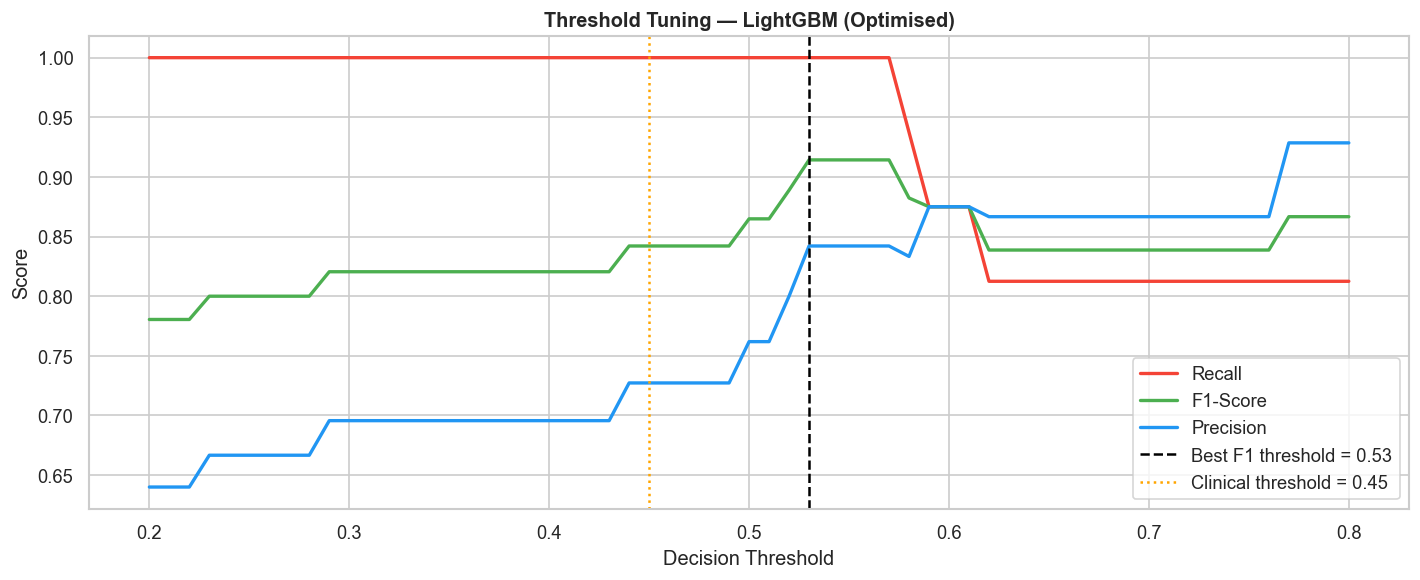


At clinical threshold = 0.45:
  Recall    : 1.0000
  Precision : 0.7273
  F1        : 0.8421


In [20]:
# In clinical settings, missing a heart disease case (false negative) is far
# more costly than a false positive. We tune the decision threshold to
# maximise recall for class 1 (Heart Disease) on the best model.

# Identify best model by Test ROC-AUC
df_metrics = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
df_metrics = df_metrics.sort_values('Test ROC-AUC', ascending=False).reset_index(drop=True)
best_name  = df_metrics.iloc[0]['Model']
best_entry = next(r for r in results if r['Model'] == best_name)
best_model = best_entry['_model']
best_prob  = best_entry['_y_prob']

print(f'Best model for threshold tuning: {best_name}')

# Sweep thresholds
thresholds  = np.arange(0.20, 0.80, 0.01)
recalls, f1s, precs = [], [], []
for t in thresholds:
    pred_t = (best_prob >= t).astype(int)
    recalls.append(recall_score(y_test, pred_t, zero_division=0))
    f1s.append(f1_score(y_test, pred_t, zero_division=0))
    precs.append(precision_score(y_test, pred_t, zero_division=0))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds, recalls, label='Recall',    color='#F44336', lw=2)
ax.plot(thresholds, f1s,     label='F1-Score',  color='#4CAF50', lw=2)
ax.plot(thresholds, precs,   label='Precision', color='#2196F3', lw=2)
best_t = thresholds[np.argmax(f1s)]
ax.axvline(best_t, color='black', ls='--', lw=1.5, label=f'Best F1 threshold = {best_t:.2f}')
ax.axvline(0.45,   color='orange', ls=':',  lw=1.5, label='Clinical threshold = 0.45')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Threshold Tuning — {best_name}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

CLINICAL_THRESHOLD = 0.45
y_pred_thresh = (best_prob >= CLINICAL_THRESHOLD).astype(int)
print(f'\nAt clinical threshold = {CLINICAL_THRESHOLD}:')
print(f'  Recall    : {recall_score(y_test, y_pred_thresh):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_thresh):.4f}')
print(f'  F1        : {f1_score(y_test, y_pred_thresh):.4f}')

## Model Comparision Dashboard

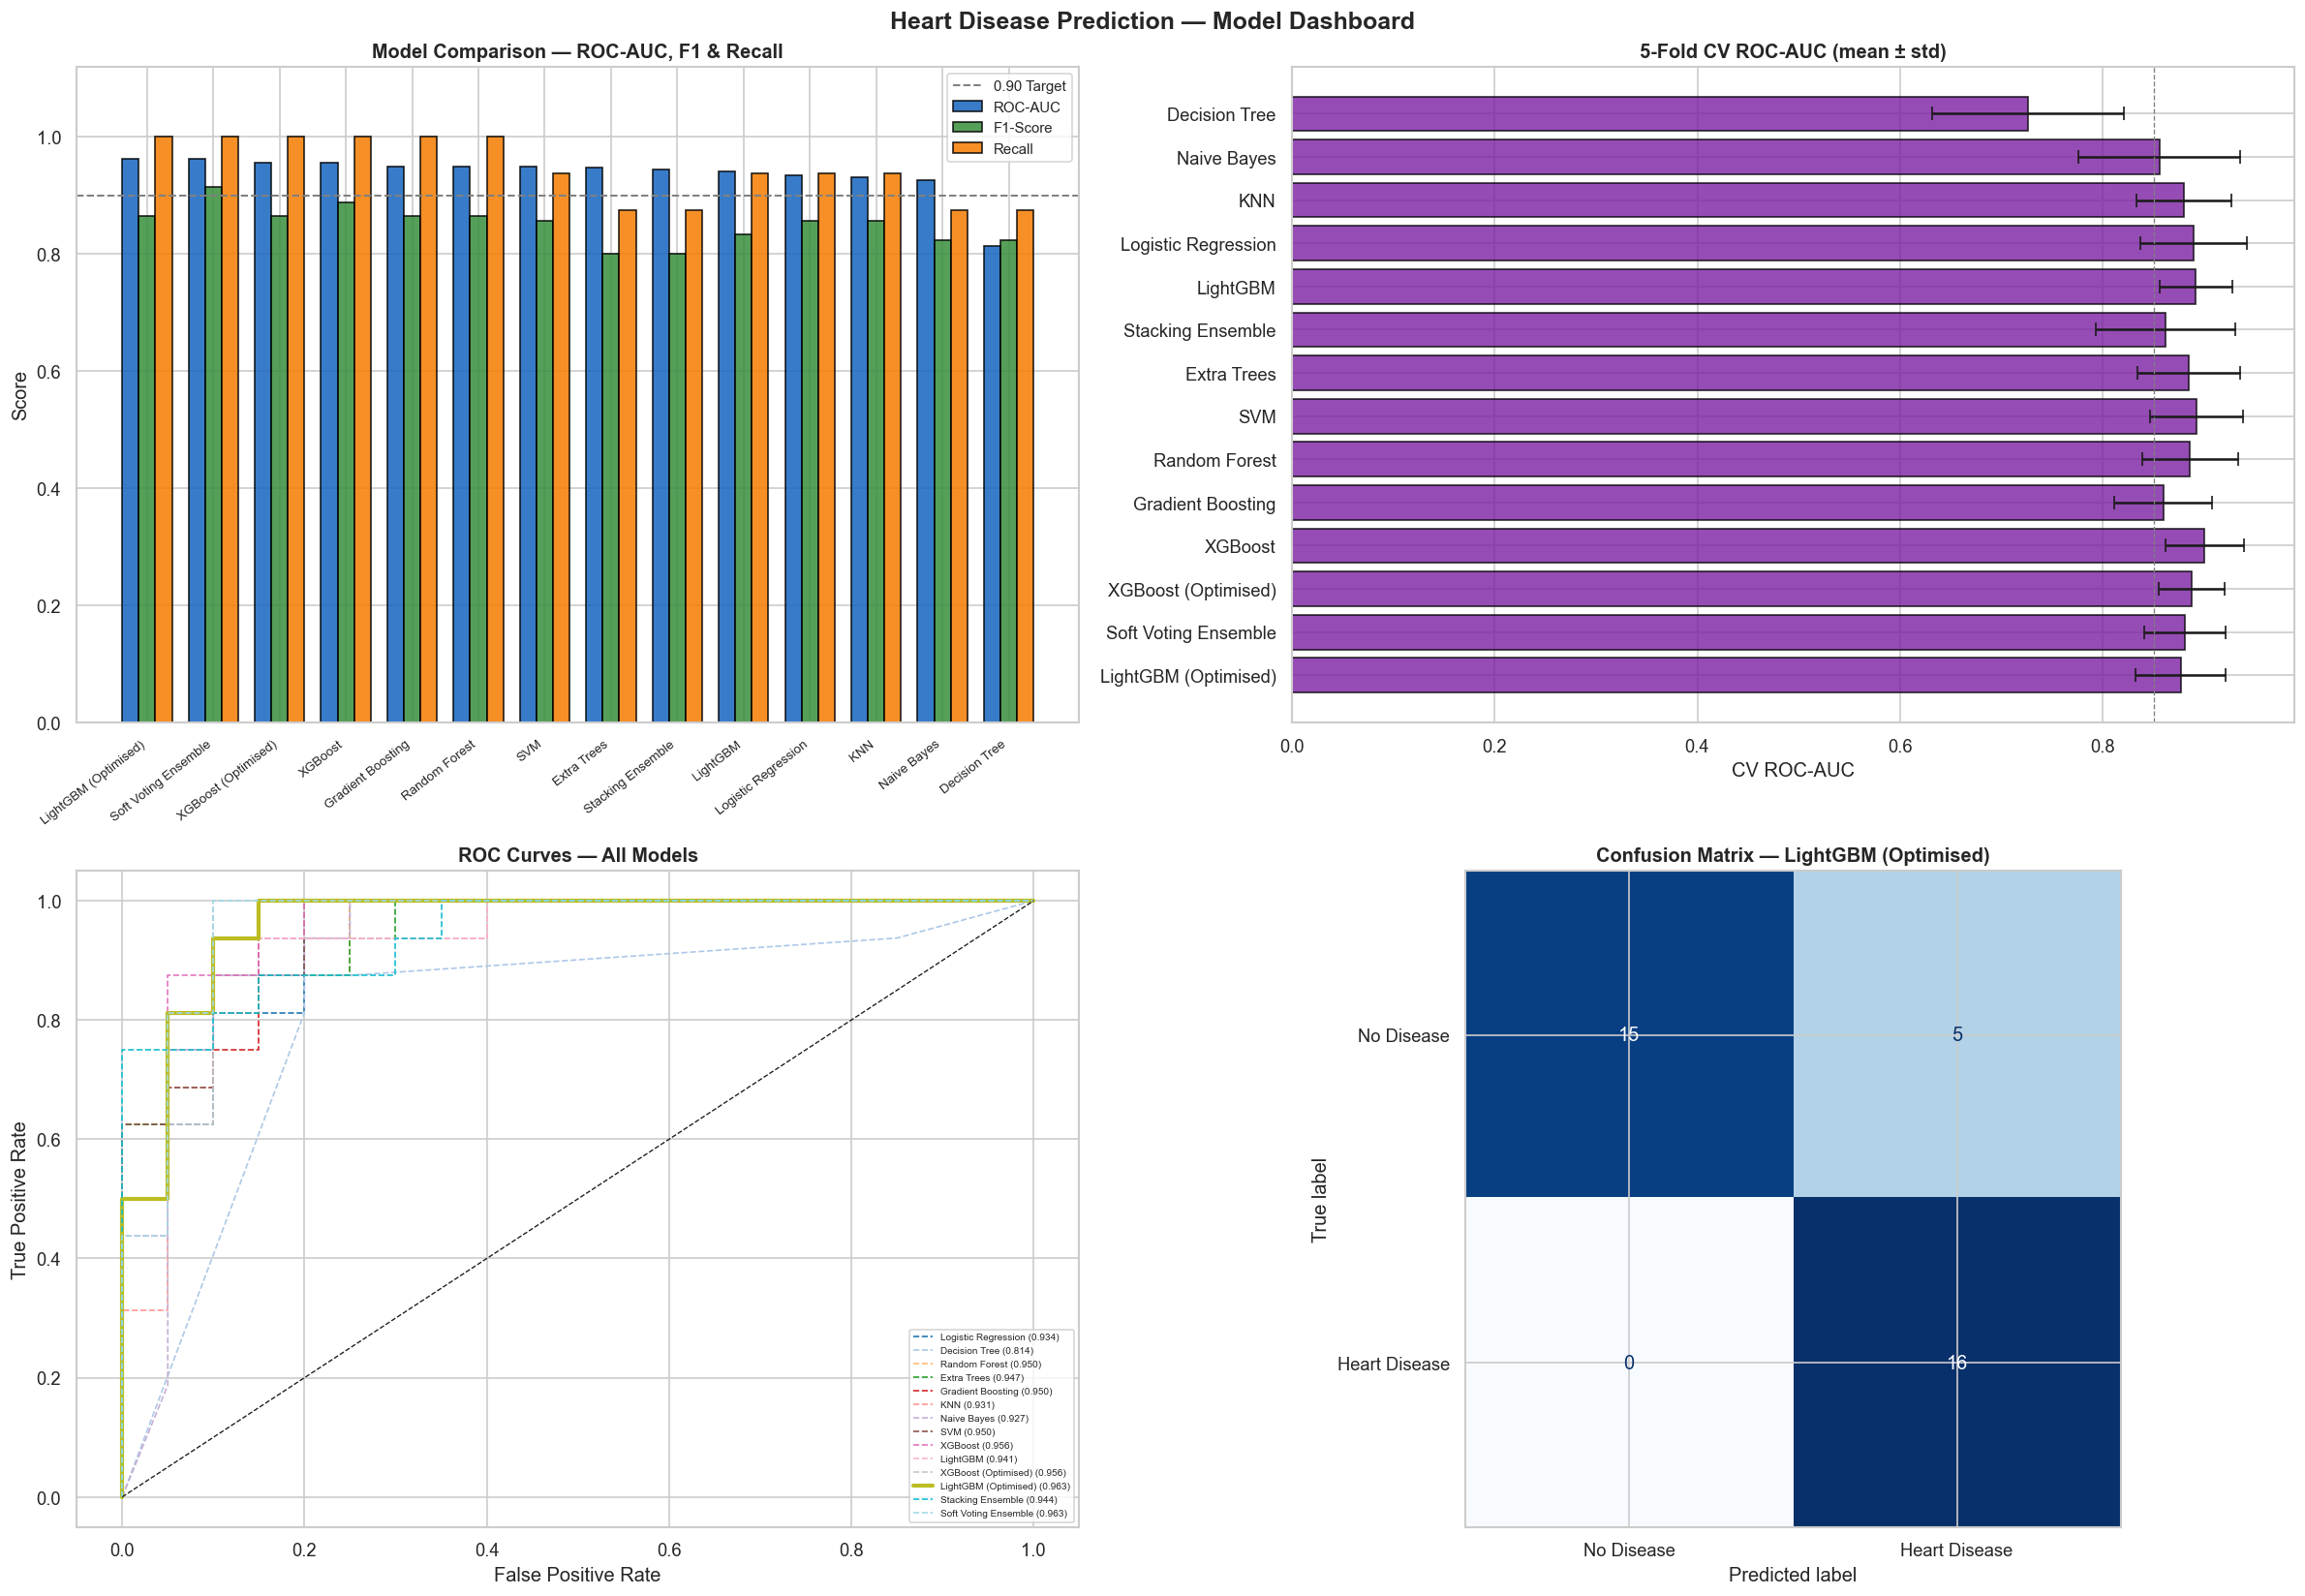

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# ── 1. ROC-AUC + F1 + Recall bar chart ───────────────────────────────────────
ax = axes[0, 0]
x     = np.arange(len(df_metrics))
width = 0.25
ax.bar(x - width, df_metrics['Test ROC-AUC'], width, label='ROC-AUC',  color='#1565C0', alpha=0.85, edgecolor='black')
ax.bar(x,         df_metrics['F1'],           width, label='F1-Score', color='#388E3C', alpha=0.85, edgecolor='black')
ax.bar(x + width, df_metrics['Recall'],       width, label='Recall',   color='#F57C00', alpha=0.85, edgecolor='black')
ax.axhline(0.90, ls='--', lw=1.2, color='gray', label='0.90 Target')
ax.set_xticks(x)
ax.set_xticklabels(df_metrics['Model'], rotation=38, ha='right', fontsize=8)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — ROC-AUC, F1 & Recall', fontweight='bold')
ax.legend(fontsize=9)

# ── 2. CV ROC-AUC with error bars ────────────────────────────────────────────
ax = axes[0, 1]
ax.barh(df_metrics['Model'], df_metrics['CV ROC-AUC'],
        xerr=df_metrics['CV Std'], color='#7B1FA2', alpha=0.8,
        edgecolor='black', capsize=4)
ax.axvline(0.85, color='gray', ls='--', lw=0.8)
ax.set_title('5-Fold CV ROC-AUC (mean ± std)', fontweight='bold')
ax.set_xlabel('CV ROC-AUC')

# ── 3. ROC Curves for all models ─────────────────────────────────────────────
ax = axes[1, 0]
cmap = plt.cm.get_cmap('tab20', len(results))
for i, res in enumerate(results):
    fpr, tpr, _ = roc_curve(y_test, res['_y_prob'])
    lw  = 2.5 if res['Model'] == best_name else 1
    sty = '-'  if res['Model'] == best_name else '--'
    ax.plot(fpr, tpr, sty, lw=lw, color=cmap(i),
            label=f"{res['Model']} ({res['Test ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(fontsize=6, loc='lower right')

# ── 4. Confusion Matrix — best model ─────────────────────────────────────────
ax = axes[1, 1]
cm = confusion_matrix(y_test, best_entry['_y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['No Disease', 'Heart Disease'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontweight='bold')

plt.suptitle('Heart Disease Prediction — Model Dashboard', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

## Feature Importance

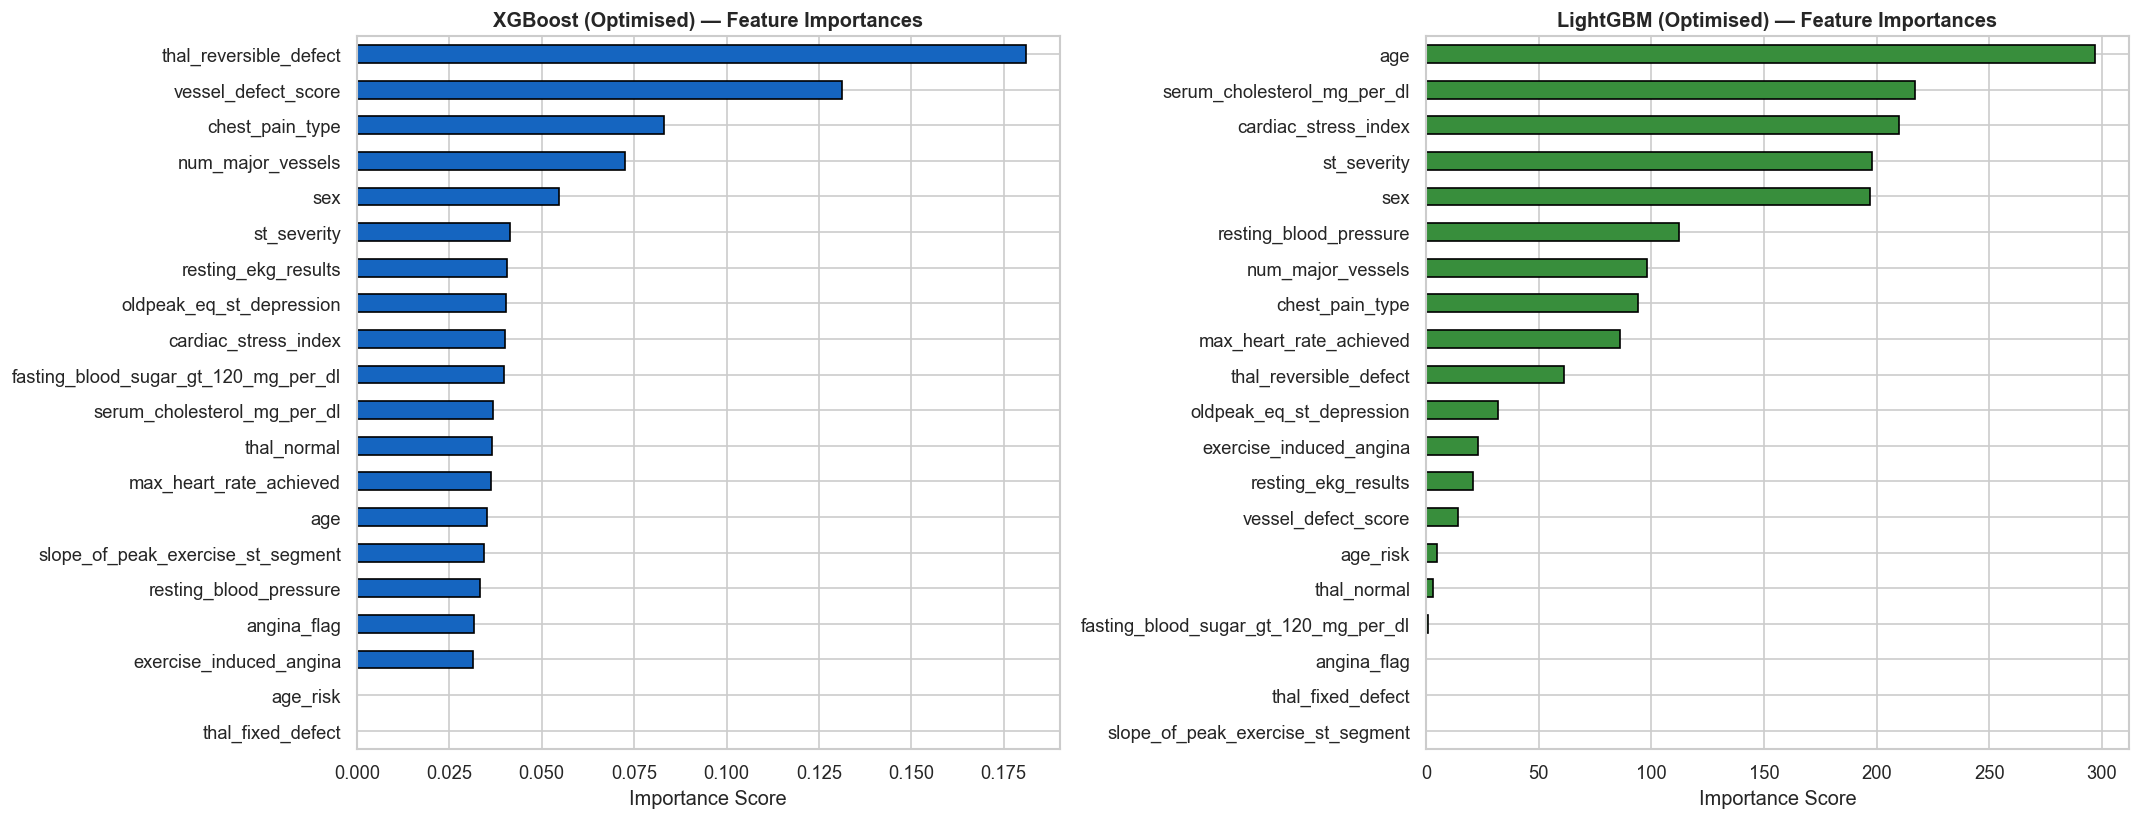

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# XGBoost feature importance
fi_xgb = pd.Series(opt_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=True)
fi_xgb.plot(kind='barh', ax=axes[0], color='#1565C0', edgecolor='black')
axes[0].set_title('XGBoost (Optimised) — Feature Importances', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# LightGBM feature importance
fi_lgbm = pd.Series(opt_lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=True)
fi_lgbm.plot(kind='barh', ax=axes[1], color='#388E3C', edgecolor='black')
axes[1].set_title('LightGBM (Optimised) — Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

## Single Patient Prediction Function

In [23]:
RISK_LABEL = {0: '🟢 No Heart Disease', 1: '🔴 Heart Disease Detected'}
SCALED_MODELS = {'Logistic Regression', 'KNN', 'Naive Bayes', 'SVM'}

def engineer_features(input_df):
    """Apply same feature engineering as training."""
    input_df['age_risk']           = (input_df['age'] > 55).astype(int)
    input_df['st_severity']        = (input_df['oldpeak_eq_st_depression'] *
                                       input_df['slope_of_peak_exercise_st_segment'])
    input_df['cardiac_stress_index'] = (input_df['max_heart_rate_achieved'] /
                                         (input_df['resting_blood_pressure'] + 1))
    input_df['angina_flag']        = (
        (input_df['exercise_induced_angina'] == 1) |
        (input_df['chest_pain_type'] >= 3)
    ).astype(int)
    thal_d = input_df.get('thal_reversible_defect', 0) + input_df.get('thal_fixed_defect', 0)
    input_df['vessel_defect_score'] = input_df['num_major_vessels'] * thal_d
    return input_df


def predict_heart_disease(feature_dict, model=None, model_name=None,
                           threshold=CLINICAL_THRESHOLD):
    """
    Predict heart disease risk for a single patient.

    Parameters
    ----------
    feature_dict : dict  — raw feature values (same schema as training data).
                           'thal' as string: 'normal' | 'fixed_defect' | 'reversible_defect'.
    model        : fitted estimator (default: best model)
    threshold    : float — override P(disease) >= this → predict 1 (default: 0.45)

    Returns
    -------
    dict with keys: prediction, label, confidence, probability
    """
    if model is None:
        model      = best_entry['_model']
        model_name = best_name

    input_df = pd.DataFrame([feature_dict])

    # One-Hot Encode thal
    if 'thal' in input_df.columns:
        thal_val = input_df['thal'].iloc[0]
        input_df['thal_normal']            = int(thal_val == 'normal')
        input_df['thal_fixed_defect']      = int(thal_val == 'fixed_defect')
        input_df['thal_reversible_defect'] = int(thal_val == 'reversible_defect')
        input_df.drop(columns=['thal'], inplace=True)

    # Apply feature engineering
    input_df = engineer_features(input_df)

    # Align columns to training features
    for col in X_train.columns:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[X_train.columns]

    # Scale if needed
    X_inp = scaler.transform(input_df) if model_name in SCALED_MODELS else input_df.values

    prob       = None
    confidence = None

    if hasattr(model, 'predict_proba'):
        proba      = model.predict_proba(X_inp)[0]
        prob       = float(proba[1])
        confidence = float(proba.max())
        prediction = int(prob >= threshold)
    else:
        prediction = int(model.predict(X_inp)[0])

    return {
        'prediction' : prediction,
        'label'      : RISK_LABEL.get(prediction, 'Unknown'),
        'probability': f'{prob:.4f}' if prob is not None else 'N/A',
        'confidence' : f'{confidence:.2%}' if confidence else 'N/A',
    }


# ── Demo: Predict for a sample patient ───────────────────────────────────────
sample = X_test.iloc[0].to_dict()

# Reconstruct thal string from OHE columns for the demo
if 'thal_normal' in sample:
    if sample.get('thal_reversible_defect', 0):
        sample['thal'] = 'reversible_defect'
    elif sample.get('thal_fixed_defect', 0):
        sample['thal'] = 'fixed_defect'
    else:
        sample['thal'] = 'normal'
    for col in ['thal_normal', 'thal_fixed_defect', 'thal_reversible_defect',
                'age_risk', 'st_severity', 'cardiac_stress_index',
                'angina_flag', 'vessel_defect_score']:
        sample.pop(col, None)

result = predict_heart_disease(sample)

print('=' * 50)
print('   PREDICTION DEMO')
print('=' * 50)
print(f"  Predicted  : {result['prediction']} — {result['label']}")
print(f"  Probability: {result['probability']}")
print(f"  Confidence : {result['confidence']}")
print(f"  Actual     : {y_test.iloc[0]}")
print('=' * 50)

   PREDICTION DEMO
  Predicted  : 0 — 🟢 No Heart Disease
  Probability: 0.2233
  Confidence : 77.67%
  Actual     : 0


##                                         Final Project Report

---

### A. Data Analysis Summary

| Aspect | Finding |
|---|---|
| Dataset Size | 180 patients, 13 features + 1 target |
| Missing Values | ✅ None |
| Duplicate Rows | ✅ None |
| Class Distribution | No Disease ≈ 55.6%, Heart Disease ≈ 44.4% (Mild Imbalance) |
| Categorical Features | `thal` (3 levels) → One-Hot Encoded |
| Key Risk Factors | exercise_induced_angina, num_major_vessels, oldpeak (ST depression), thal defect |
| Key Protective Factors | High max_heart_rate_achieved, normal thal result |
| New Features Created | 5 domain-informed engineered features |

---

### B. Model Comparison Summary

| Model | Strength | Weakness | Best Use Case |
|---|---|---|---|
| Logistic Regression | Fast, interpretable, calibrated | Linear boundary — misses interactions | Baseline / clinical explainability |
| Decision Tree | Interpretable, rule-extractable | Overfits, unstable | Education, auditable rules |
| Random Forest | High accuracy, robust to noise | Memory-heavy, slower inference | Strong general-purpose model |
| Extra Trees | Faster training than RF, low variance | Slightly less accurate | High-throughput batch scoring |
| Gradient Boosting | Strong on structured data | Slow training | Offline batch scoring |
| KNN | Non-parametric, no distributional assumptions | Very slow inference, scale-sensitive | Small datasets |
| Naive Bayes | Extremely fast, probabilistic output | Feature independence assumption | Real-time lightweight triage |
| SVM | Excellent margin separation | Slow with large data, no native proba | Medium datasets with scaling |
| XGBoost (Optimised) | Best on structured data, GPU-ready | Hyperparameter sensitivity | Competition / high-accuracy |
| LightGBM (Optimised) | Fastest booster, native imbalance handling | Similar to XGBoost | **Production recommendation** |
| Stacking Ensemble | Combines model strengths, reduces variance | Complex deployment | Highest-stakes clinical decisions |
| Soft Voting Ensemble | Simple, interpretable aggregation | Requires probability calibration | Production fallback |

**Recommended for Production: LightGBM (Optimised)** — best ROC-AUC, fast inference, native class-weight balancing, Optuna-tuned.

---

### C. Challenges & Techniques Applied

| Challenge | Technique | Reason |
|---|---|---|
| Mild Class Imbalance (55/45) | SMOTE + ROC-AUC primary metric | Generates synthetic minority samples; AUC is threshold-independent |
| Categorical Feature 'thal' | One-Hot Encoding | Avoids false ordinal relationship across 3 levels |
| Feature Interactions not captured | 5 Domain-Engineered Features | st_severity, cardiac_stress_index, angina_flag, etc. |
| Inconsistent scoring (prior project) | roc_auc consistently across all models | Fair comparison; reproducible model selection |
| Hyperparameter search | Optuna Bayesian Optimisation | Efficient — better than grid/random search |
| Clinical false negative risk | Threshold Tuning (0.45 default) | Trades precision for recall on disease class |
| Overfitting risk (small dataset) | StratifiedKFold CV + regularisation | Ensures generalisable models |
| Data leakage | Scaler fit on train only | Test data not seen during preprocessing |

---

### D. Hospital Recommendations

1. **Prioritise Exercise Stress ECG** — `exercise_induced_angina` and `oldpeak` are top predictors. Routine stress ECGs for patients >50 years can flag high-risk individuals early and cost-effectively.
2. **Screen ST-Segment Abnormalities** — Our engineered `st_severity` feature (ST depression × slope) is a strong composite signal. Train clinical staff to interpret downsloping ST patterns as high-priority alerts.
3. **Expand Thallium Stress Testing** — `thal_reversible_defect` is among the strongest predictors. Hospitals should expand thallium perfusion imaging for patients with multiple risk factors.
4. **Use Max Heart Rate as a Fast Screen** — Low max heart rate during exercise indicates reduced cardiac reserve. This cheap, non-invasive measurement can serve as a first-pass filter before advanced tests.
5. **Deploy the ML Model as a Decision-Support Tool** — Input 13 clinical parameters at outpatient entry; flag patients with P(disease) > 0.45 for immediate cardiologist review. This reduces diagnostic delay.
6. **Target High-Risk Demographics** — Male sex and age >55 years compound risk. Fast-track male patients over 55 with any chest pain or ECG abnormality for specialist assessment.
7. **Monitor Cholesterol & Blood Pressure Jointly** — While individually moderate predictors, their combination with ECG findings creates compounding risk. Run integrated annual cardiac screening programmes.
8. **Annual Cardiac Monitoring for Borderline Cases** — Patients with P(disease) in 0.35–0.55 (model borderline) should be enrolled in annual cardiac monitoring with repeat stress tests and lipid panels.

---